# Static
Author: Yunsik Kim

## 1. Set working environment and load data

In [ ]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

print(os.getcwd())

/Users/yunsik/Library/CloudStorage/OneDrive-Personal/Charlotte/Coursework/04-Spring2026/GEOG8005/GeoViz_Live/Project


In [ ]:
input_path = 'input'

station = pd.read_csv(os.path.join(input_path, 'Station.csv'), encoding='euc-kr')
seoul = gpd.read_file(os.path.join(input_path, 'bnd/seoul.shp'))

station.columns = ['stationID', 'address1', 'address2', 'lat', 'long']
station = station[['stationID', 'lat', 'long']]
station = station[(station['lat'] != 0) & (station['long'] != 0)].copy()

station_gdf = gpd.GeoDataFrame(station, geometry=gpd.points_from_xy(station['long'], station['lat']), crs='EPSG:4326').to_crs(epsg=5179)
station_gdf = gpd.clip(station_gdf, seoul)
station_gdf.head()

,stationID,lat,long,geometry
2381,ST-1932,37.436981,126.903297,POINT (947212.833 1937701.961)
2697,ST-1648,37.437271,126.902687,POINT (947159.073 1937734.476)
410,ST-628,37.443340,126.903358,POINT (947222.695 1938407.414)
2382,ST-1931,37.446526,126.900238,POINT (946948.956 1938762.631)
412,ST-626,37.446861,126.903831,POINT (947267.008 1938797.78)


## 2. Delineate service areas

<Axes: >

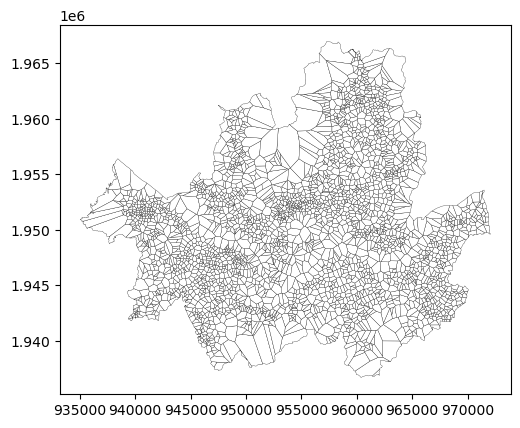

In [ ]:
from shapely.ops import voronoi_diagram
from shapely.geometry import MultiPoint

# Create voronoi
points = MultiPoint(station_gdf.geometry.tolist())
vor = voronoi_diagram(points)

station_vor = gpd.GeoDataFrame(
    geometry=list(vor.geoms),
    crs=station_gdf.crs
)

# Join stationID
station_vor = gpd.sjoin(
    station_vor,
    station_gdf[['stationID','geometry']],
    how="left",
    predicate="contains"
)

# Clip
station_vor_clip = gpd.clip(station_vor, seoul)
station_vor_clip.plot(edgecolor='black', linewidth=0.2, facecolor='white')

## 3. Count trip data

In [ ]:
import glob
import pyarrow.parquet as pq

input_parquet = 'input/trip_parquet'
files = sorted(glob.glob(os.path.join(input_parquet, 'trip_2025-*.parquet')))
print(len(files))

365


In [ ]:
total_filtered = 0

for f in files:
    table = pq.read_table(f)
    df = table.to_pandas(types_mapper=None)
    
    df = df[(df['USE_DST'] > 200) & (df['USE_MIN'] > 0)]
    total_filtered += len(df)
    
    del df

print("Total filtered trips in 2025:", total_filtered)

Total filtered trips in 2025: 36298179


## 4. Annual average trip count

In [ ]:
import glob

input_parquet = 'input/trip_parquet'
files = sorted(glob.glob(os.path.join(input_parquet, 'trip_2025-*.parquet')))
print(len(files))

365


In [ ]:
# 7x24 집계 테이블 초기화
agg = np.zeros((7, 24), dtype=np.float64)

# 요일별 날짜 개수 세기
weekday_per_count = np.zeros(7, dtype=int)

for f in files:
    print('Processing:', os.path.basename(f))

    # 1. Read parquet data
    table = pq.read_table(f)
    df = table.to_pandas(types_mapper=None)
    df = df[(df['USE_DST'] > 200) & (df['USE_MIN'] > 0)].copy()

    # 2. Create temporal variables
    df['weekday'] = df['RENT_DT'].dt.weekday
    df['hour'] = df['RENT_DT'].dt.hour

    # 3. Date of current file
    file_date = df['RENT_DT'].dt.date.iloc[0]
    wd = df['weekday'].iloc[0]
    weekday_per_count[wd] += 1

    # 4. Day x hour aggregation
    counts = df.groupby(['weekday', 'hour']).size()

    for (w,h), val in counts.items():
        agg[w, h] += val
    
    del df

print("Finished aggregation")

Processing: trip_2025-01-01.parquet
Processing: trip_2025-01-02.parquet
Processing: trip_2025-01-03.parquet
Processing: trip_2025-01-04.parquet
Processing: trip_2025-01-05.parquet
Processing: trip_2025-01-06.parquet
Processing: trip_2025-01-07.parquet
Processing: trip_2025-01-08.parquet
Processing: trip_2025-01-09.parquet
Processing: trip_2025-01-10.parquet
Processing: trip_2025-01-11.parquet
Processing: trip_2025-01-12.parquet
Processing: trip_2025-01-13.parquet
Processing: trip_2025-01-14.parquet
Processing: trip_2025-01-15.parquet
Processing: trip_2025-01-16.parquet
Processing: trip_2025-01-17.parquet
Processing: trip_2025-01-18.parquet
Processing: trip_2025-01-19.parquet
Processing: trip_2025-01-20.parquet
Processing: trip_2025-01-21.parquet
Processing: trip_2025-01-22.parquet
Processing: trip_2025-01-23.parquet
Processing: trip_2025-01-24.parquet
Processing: trip_2025-01-25.parquet
Processing: trip_2025-01-26.parquet
Processing: trip_2025-01-27.parquet
Processing: trip_2025-01-28.

In [ ]:
avg_agg = np.zeros_like(agg)

for w in range(7):
    if weekday_per_count[w] > 0:
        avg_agg[w, :] = agg[w, :] / weekday_per_count[w]

In [ ]:
hourly_avg = pd.DataFrame(
    avg_agg,
    index=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    columns=range(24)
)

hourly_avg

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Mon,1598.307692,986.884615,668.634615,519.673077,528.826923,1248.519231,2842.096154,6876.153846,9685.653846,4687.961538,...,3912.653846,4597.480769,5713.211538,8726.442308,11578.519231,7211.923077,5843.211538,5136.403846,4109.788462,2374.250000
Tue,1682.807692,1189.576923,798.750000,595.173077,578.346154,1289.634615,2856.000000,6863.307692,10049.423077,4915.038462,...,3918.211538,4415.269231,6182.980769,9127.461538,11763.173077,7508.980769,6117.980769,5528.903846,4488.884615,2621.250000
Wed,1905.056604,1337.226415,874.226415,643.886792,601.150943,1330.471698,3023.547170,7295.490566,10340.509434,4950.735849,...,4019.075472,4631.056604,5854.094340,8829.037736,11308.924528,7108.735849,5860.018868,5370.150943,4408.830189,2644.283019
Thu,1927.942308,1341.884615,863.653846,630.730769,579.365385,1236.365385,2767.826923,6732.730769,9873.019231,4892.596154,...,4263.846154,4871.307692,6611.769231,9476.846154,12062.961538,7768.326923,6364.923077,5742.557692,4751.730769,2876.000000
Fri,2103.730769,1472.250000,982.942308,709.750000,619.500000,1233.173077,2686.557692,6453.788462,9245.442308,4665.192308,...,4407.269231,5122.884615,6130.403846,8418.750000,9830.730769,6225.576923,4942.442308,4397.769231,3956.730769,2620.153846
Sat,2090.980769,1617.788462,1083.980769,780.326923,579.153846,699.615385,1033.000000,1688.750000,2800.750000,3484.423077,...,5158.807692,5448.307692,5796.250000,5739.480769,5335.884615,4657.461538,4405.826923,4271.019231,3607.365385,2617.057692
Sun,2260.076923,1621.230769,1140.307692,795.769231,555.576923,620.980769,954.750000,1495.423077,2387.038462,3113.846154,...,5578.153846,6041.980769,6439.769231,6550.807692,6101.423077,5344.461538,4811.192308,4303.634615,3218.788462,2107.807692


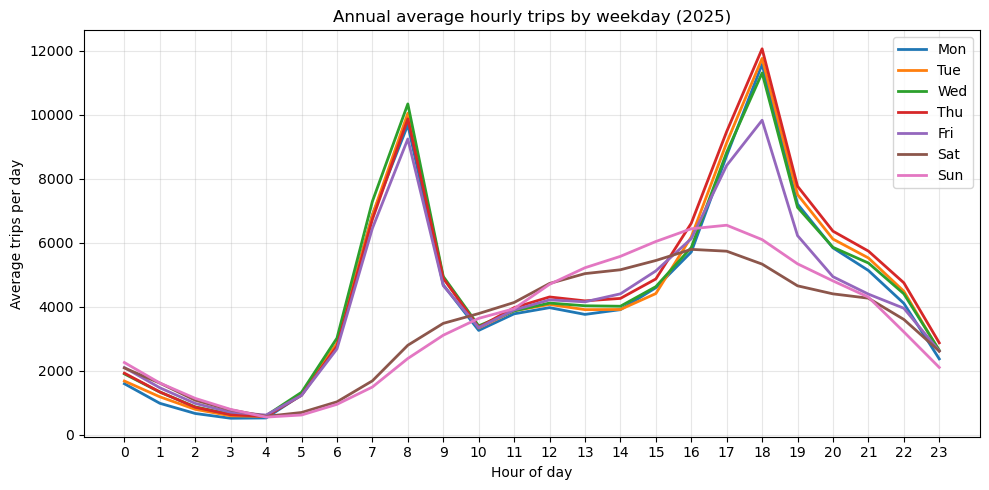

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for wd in range(7):
    plt.plot(
        range(24),
        hourly_avg.iloc[wd],
        label=hourly_avg.index[wd],
        linewidth=2
    )

plt.xlabel("Hour of day")
plt.ylabel("Average trips per day")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)
plt.title("Annual average hourly trips by weekday (2025)")
plt.tight_layout()
plt.show()

## 5. Annual average outflow/inflow

In [ ]:
from collections import defaultdict

inflow_sum = defaultdict(int)
outflow_sum = defaultdict(int)

n_days = 0

for f in files:
    print('Processing:', os.path.basename(f))

    table = pq.read_table(f)
    df = table.to_pandas(types_mapper=None)
    df = df[(df['USE_DST'] > 200) & (df['USE_MIN'] > 0)].copy()

    inflow = df.groupby('RETURN_STATION_ID').size()
    for sid, val in inflow.items():
        inflow_sum[sid] += val

    outflow = df.groupby('RENT_STATION_ID').size()
    for sid, val in outflow.items():
        outflow_sum[sid] += val

    n_days += 1

    del df

print('Finished aggregation.')
print('Total days processed:', n_days)

Processing: trip_2025-01-01.parquet
Processing: trip_2025-01-02.parquet
Processing: trip_2025-01-03.parquet
Processing: trip_2025-01-04.parquet
Processing: trip_2025-01-05.parquet
Processing: trip_2025-01-06.parquet
Processing: trip_2025-01-07.parquet
Processing: trip_2025-01-08.parquet
Processing: trip_2025-01-09.parquet
Processing: trip_2025-01-10.parquet
Processing: trip_2025-01-11.parquet
Processing: trip_2025-01-12.parquet
Processing: trip_2025-01-13.parquet
Processing: trip_2025-01-14.parquet
Processing: trip_2025-01-15.parquet
Processing: trip_2025-01-16.parquet
Processing: trip_2025-01-17.parquet
Processing: trip_2025-01-18.parquet
Processing: trip_2025-01-19.parquet
Processing: trip_2025-01-20.parquet
Processing: trip_2025-01-21.parquet
Processing: trip_2025-01-22.parquet
Processing: trip_2025-01-23.parquet
Processing: trip_2025-01-24.parquet
Processing: trip_2025-01-25.parquet
Processing: trip_2025-01-26.parquet
Processing: trip_2025-01-27.parquet
Processing: trip_2025-01-28.

In [ ]:
avg_inflow = {k: v / n_days for k, v in inflow_sum.items()}
avg_outflow = {k: v / n_days for k, v in outflow_sum.items()}

station_avg = pd.DataFrame({
    'stationID': list(avg_inflow.keys()),
    'avg_inflow': list(avg_inflow.values())
})

station_avg['avg_outflow'] = station_avg['stationID'].map(avg_outflow).fillna(0)

station_avg.head()

,stationID,avg_inflow,avg_outflow
0,ST-10,41.079452,39.780822
1,ST-1000,50.542466,47.252055
2,ST-1002,95.635616,91.879452
3,ST-1004,10.153425,22.934247
4,ST-1005,87.994521,88.405479


In [ ]:
station_vor_clip = station_vor_clip.merge(
    station_avg,
    on="stationID",
    how="left"
)

station_vor_clip[['avg_inflow','avg_outflow']] = station_vor_clip[['avg_inflow','avg_outflow']].fillna(0)

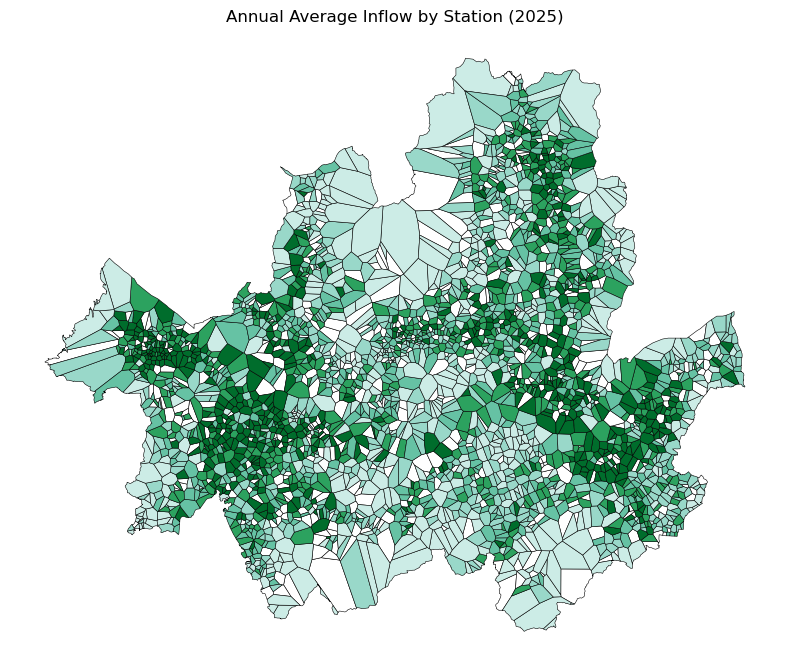

In [ ]:
import mapclassify

zero_data = station_vor_clip[station_vor_clip["avg_inflow"] == 0]
nonzero_data = station_vor_clip[station_vor_clip["avg_inflow"] > 0]

scheme = mapclassify.Quantiles(
    nonzero_data["avg_inflow"],
    k=5
)

custom_colors = [
    "#ccece6",
    "#99d8c9",
    "#66c2a4",
    "#2ca25f",
    "#006d2c"
]

nonzero_data["class"] = scheme.yb

nonzero_data["color"] = nonzero_data["class"].apply(
    lambda x: custom_colors[x]
)

fix, ax = plt.subplots(figsize=(8, 8))

zero_data.plot(
    ax=ax,
    color="#ffffff",
    edgecolor="black",
    linewidth=0.4
)

nonzero_data.plot(
    # column="avg_inflow",
    color=nonzero_data['color'],
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.4
)

ax.set_title("Annual Average Inflow by Station (2025)")
ax.set_axis_off()

plt.tight_layout()
plt.show()

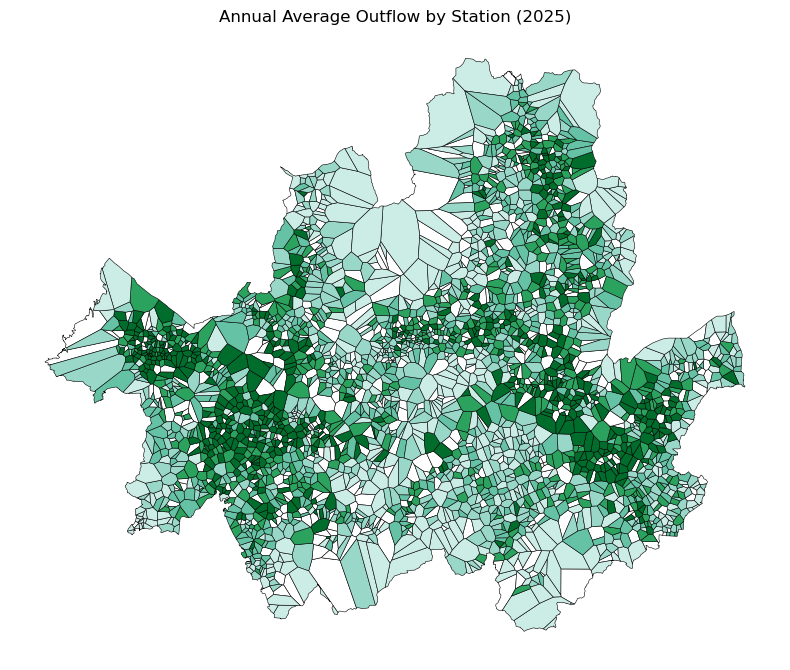

In [ ]:
import mapclassify

zero_data = station_vor_clip[station_vor_clip["avg_outflow"] == 0]
nonzero_data = station_vor_clip[station_vor_clip["avg_outflow"] > 0]

scheme = mapclassify.Quantiles(
    nonzero_data["avg_outflow"],
    k=5
)

custom_colors = [
    "#ccece6",
    "#99d8c9",
    "#66c2a4",
    "#2ca25f",
    "#006d2c"
]

nonzero_data["class"] = scheme.yb

nonzero_data["color"] = nonzero_data["class"].apply(
    lambda x: custom_colors[x]
)

fix, ax = plt.subplots(figsize=(8, 8))

zero_data.plot(
    ax=ax,
    color="#ffffff",
    edgecolor="black",
    linewidth=0.4
)

nonzero_data.plot(
    # column="avg_outflow",
    color=nonzero_data['color'],
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.4
)

ax.set_title("Annual Average Outflow by Station (2025)")
ax.set_axis_off()

plt.tight_layout()
plt.show()

## 6. Annual average outflow/inflow (weekdays vs. weekend)

In [ ]:
from collections import defaultdict
import glob
import os
import pyarrow.parquet as pq

input_path = "input/trip_parquet"
files = sorted(glob.glob(os.path.join(input_path, "trip_2025-*.parquet")))

# 누적
wd_inflow = defaultdict(int)
wd_outflow = defaultdict(int)
we_inflow = defaultdict(int)
we_outflow = defaultdict(int)

weekday_days = 0
weekend_days = 0

In [ ]:
for f in files:
    table = pq.read_table(f)
    df = table.to_pandas(types_mapper=None)
    df = df[(df['USE_DST'] > 200) & (df['USE_MIN'] > 0)].copy()
    
    df["weekday"] = df["RENT_DT"].dt.weekday
    day_type = df["weekday"].iloc[0]  # 하루치 파일이니까 동일
    
    # weekday (0~4)
    if day_type < 5:
        weekday_days += 1
        
        inflow = df.groupby("RETURN_STATION_ID").size()
        for sid, val in inflow.items():
            wd_inflow[sid] += val
        
        outflow = df.groupby("RENT_STATION_ID").size()
        for sid, val in outflow.items():
            wd_outflow[sid] += val
    
    # weekend (5~6)
    else:
        weekend_days += 1
        
        inflow = df.groupby("RETURN_STATION_ID").size()
        for sid, val in inflow.items():
            we_inflow[sid] += val
        
        outflow = df.groupby("RENT_STATION_ID").size()
        for sid, val in outflow.items():
            we_outflow[sid] += val
    
    del df

In [ ]:
import pandas as pd

station_ids = set(
    list(wd_inflow.keys()) +
    list(we_inflow.keys()) +
    list(wd_outflow.keys()) +
    list(we_outflow.keys())
)

station_avg = pd.DataFrame({"stationID": list(station_ids)})

station_avg["wd_avg_inflow"] = station_avg["stationID"].map(
    lambda x: wd_inflow[x] / weekday_days if weekday_days > 0 else 0
)

station_avg["wd_avg_outflow"] = station_avg["stationID"].map(
    lambda x: wd_outflow[x] / weekday_days if weekday_days > 0 else 0
)

station_avg["we_avg_inflow"] = station_avg["stationID"].map(
    lambda x: we_inflow[x] / weekend_days if weekend_days > 0 else 0
)

station_avg["we_avg_outflow"] = station_avg["stationID"].map(
    lambda x: we_outflow[x] / weekend_days if weekend_days > 0 else 0
)

In [ ]:
station_vor_clip = station_vor_clip.merge(
    station_avg,
    on="stationID",
    how="left"
)

station_vor_clip = station_vor_clip.fillna(0)

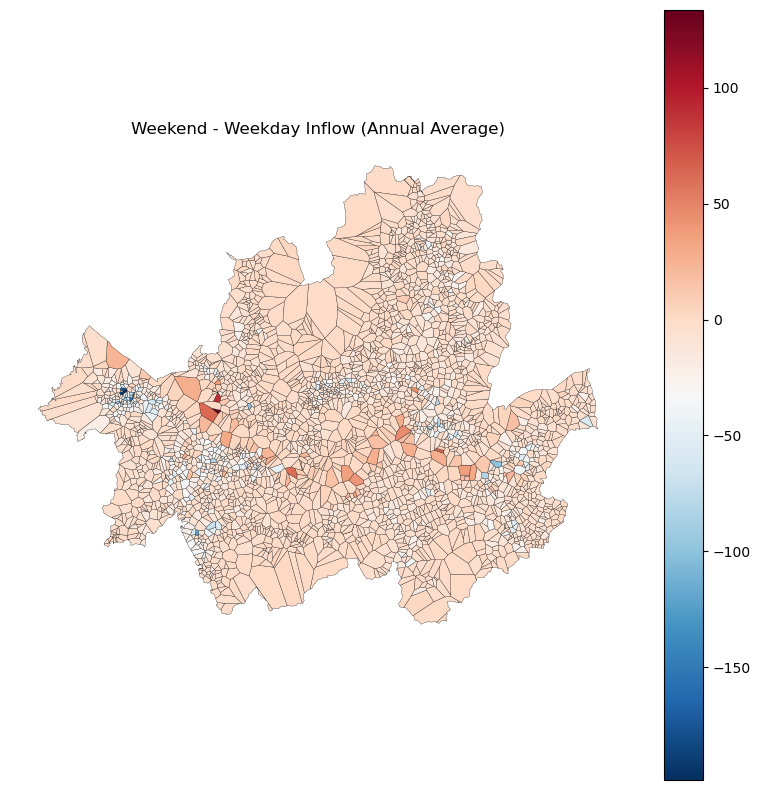

In [ ]:
# Difference map
station_vor_clip["diff_inflow"] = (
    station_vor_clip["we_avg_inflow"] -
    station_vor_clip["wd_avg_inflow"]
)

station_vor_clip["diff_outflow"] = (
    station_vor_clip["we_avg_outflow"] -
    station_vor_clip["wd_avg_outflow"]
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

station_vor_clip.plot(
    column="diff_inflow",
    cmap="RdBu_r",   # diverging
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

ax.set_title("Weekend - Weekday Inflow (Annual Average)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
v = abs(station_vor_clip["diff_inflow"]).max()

station_vor_clip.plot(
    column="diff_inflow",
    cmap="RdBu_r",
    vmin=-v,
    vmax=v,
    legend=True,
    ax=ax
)